# Notebook 02 — Pearson Correlation & Time Series
**Part A — Temporal analysis**

## What this notebook does
1. Computes Pearson correlations between all 7 meteorological variables and 4 bioaerosol targets  
2. Produces the **correlation heatmap** with significance stars (Fig 2 in paper)  
3. Produces the **daily time series** plot across all 6 stations (Fig 1 in paper)  
4. Prints the full numeric correlation table

## Inputs
- `df_analysis.csv` — output from Notebook 01

### Action Required: Generate `df_analysis.csv`

The `df_analysis.csv` file, which is an input for this notebook, is generated by `01_data_preparation.ipynb`. Please run the `01_data_preparation.ipynb` notebook first to create this file. Once it has finished executing, you can return to this notebook and proceed.

In [42]:
# Re-run the 01_data_preparation.ipynb notebook to ensure df_analysis.csv is generated.
# This should create 'data/df_analysis.csv' in the current working directory.
%run 01_data_preparation.ipynb

# Verify if df_analysis.csv now exists in the 'data' directory
print("\nVerifying contents of data/ directory after running 01_data_preparation.ipynb:")
!ls -F data/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cloning into 'geoai-bioaerosol-prediction'...
remote: Enumerating objects: 178, done.
remote: Counting objects: 100% (178/178), done.
remote: Compressing objects: 100% (177/177), done.
remote: Total 178 (delta 59), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (178/178), 4.64 MiB | 18.27 MiB/s, done.
Resolving deltas: 100% (59/59), done.
Current directory: /content/geoai-bioaerosol-prediction/geoai-bioaerosol-prediction
Python: 3.12.13 (m
Libraries loaded successfully.
Loaded 64 rows
Stations: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Dates: ['2016-04-04', '2016-04-05', '2016-04-06', '2016-04-07', '2016-04-08', '2016-04-12', '2016-04-13', '2016-04-14', '2016-04-15', '2016-04-18', '2016-04-19', '2016-04-20']
Rod area  = 0.0015 × 0.035 × 2 = 0.000105 m²
D         = 0.1148 m
RPM       = 2700
Formula   : C

Once the above cell finishes execution, `df_analysis.csv` should be present in the `data/` directory. Please re-run cell `xQs-PT9HNvB_` to load the data and proceed with the analysis.

In [40]:
# ===================================================================
# COLAB SETUP — run this cell first if using Google Colab
# ===================================================================
import os, sys

# Ensure we are in /content before attempting to clean up and clone
os.chdir('/content')

# Clean up any previous clone to avoid nesting issues
!rm -rf geoai-bioaerosol-prediction

# Clone the GitHub repo
!git clone https://github.com/Filza-coder/geoai-bioaerosol-prediction.git

# Change into the repository directory
os.chdir('geoai-bioaerosol-prediction') # Now we are definitely in /content/geoai-bioaerosol-prediction

# Install system-level GDAL dependencies
!apt-get update -qq && apt-get install -y -qq libgdal-dev

# Install Python dependencies
!pip install openpyxl geopandas shapely pyproj scikit-learn shap seaborn -q

print('Current directory:', os.getcwd())
print('Python:', sys.version[:10])

# List all files to verify contents and locate df_analysis.csv
print('\nRepository contents:')
!ls -R

Cloning into 'geoai-bioaerosol-prediction'...
remote: Enumerating objects: 178, done.
remote: Counting objects: 100% (178/178), done.
remote: Compressing objects: 100% (177/177), done.
remote: Total 178 (delta 59), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (178/178), 4.64 MiB | 17.15 MiB/s, done.
Resolving deltas: 100% (59/59), done.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Current directory: /content/geoai-bioaerosol-prediction
Python: 3.12.13 (m

Repository contents:
.:
 01_data_preparation.ipynb			 grassland1.dbf
 02_pearson_correlation_timeseries.ipynb	 grassland1.prj
 03_random_forest_permutation_importance.ipynb	 grassland1.sbn
 04_shap_analysis.ipynb				 grassland1.sbx
 05_lulc_spatial_analysis.ipynb			 grassland1.shp
 06_height_gradient_analysis.ipynb		 grassland1.shx
 alongroadsfinal.cpg				 grasslands
 alo

In [43]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Debugging path issue
print(f"Current working directory: {os.getcwd()}")
print("Listing contents of current working directory:")
!ls -F

print("\nSearching for df_analysis.csv across /content/:")
!find /content -name df_analysis.csv

# Load dataset
# The file was saved in geoai-bioaerosol-prediction/data/ because of nested execution.
# Corrected path based on current working directory
df = pd.read_csv('data/df_analysis.csv')
for col in ['Aspergillus_conc', 'Alternaria_conc']:
    df[col] = df[col].fillna(df[col].median())

# ── Define variables ─────────────────────────────────────────────
MET_FEATURES = ['GHI', 'Tamb', 'RH', 'WS', 'BP', 'sin_WD', 'cos_WD']
FEAT_LABELS  = ['GHI', 'Temp', 'RH', 'Wind Speed', 'Pressure', 'sin(WD)', 'cos(WD)']

TARGETS = {
    'pollen_conc':      'Pollen (grain/m³)',
    'fungus_conc':      'Total Fungus (grain/m³)',
    'Aspergillus_conc': 'Aspergillus (grain/m³)',
    'Alternaria_conc':  'Alternaria (grain/m³)',
}
COLORS = {
    'pollen_conc':      '#378ADD',
    'fungus_conc':      '#D85A30',
    'Aspergillus_conc': '#1D9E75',
    'Alternaria_conc':  '#BA7517',
}

print(f'Dataset: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Stations: {sorted(df["station"].unique())}')
print(f'Dates:    {df["date"].nunique()} unique dates')

Current working directory: /content/geoai-bioaerosol-prediction/geoai-bioaerosol-prediction
Listing contents of current working directory:
 01_data_preparation.ipynb			 grassland1.cpg
 02_pearson_correlation_timeseries.ipynb	 grassland1.dbf
 03_random_forest_permutation_importance.ipynb	 grassland1.prj
 04_shap_analysis.ipynb				 grassland1.sbn
 05_lulc_spatial_analysis.ipynb			 grassland1.sbx
 06_height_gradient_analysis.ipynb		 grassland1.shp
 alongroadsfinal.cpg				 grassland1.shx
 alongroadsfinal.dbf				 grasslands/
 alongroadsfinal.prj				 insidegrasstotal.cpg
 alongroadsfinal.sbn				 insidegrasstotal.dbf
 alongroadsfinal.sbx				 insidegrasstotal.prj
 alongroadsfinal.shp				 insidegrasstotal.sbn
 alongroadsfinal.shp.xml			 insidegrasstotal.sbx
 alongroadsfinal.shx				 insidegrasstotal.shp
'barren land'/					 insidegrasstotal.shp.xml
 barren_land.cpg				 insidegrasstotal.shx
 barren_land.dbf				 nust.png
 barren_land.prj				 portion2.cpg
 barren_land.sbn				 portion2.dbf
 barren_la

In [ ]:
# Verify if df_analysis.csv exists in the current directory
!ls -F

### Running `01_data_preparation.ipynb`

To generate `df_analysis.csv`, you can run `01_data_preparation.ipynb` directly from this notebook using the `%run` magic command. This will execute all the cells in that notebook, and upon completion, `df_analysis.csv` should be created in the current working directory.

In [44]:
# Run the 01_data_preparation.ipynb notebook to generate df_analysis.csv
%run 01_data_preparation.ipynb

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cloning into 'geoai-bioaerosol-prediction'...
remote: Enumerating objects: 178, done.
remote: Counting objects: 100% (178/178), done.
remote: Compressing objects: 100% (177/177), done.
remote: Total 178 (delta 59), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (178/178), 4.64 MiB | 18.63 MiB/s, done.
Resolving deltas: 100% (59/59), done.
Current directory: /content/geoai-bioaerosol-prediction/geoai-bioaerosol-prediction/geoai-bioaerosol-prediction
Python: 3.12.13 (m
Libraries loaded successfully.
Loaded 64 rows
Stations: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Dates: ['2016-04-04', '2016-04-05', '2016-04-06', '2016-04-07', '2016-04-08', '2016-04-12', '2016-04-13', '2016-04-14', '2016-04-15', '2016-04-18', '2016-04-19', '2016-04-20']
Rod area  = 0.0015 × 0.035 × 2 = 0.000105 m²
D         = 0.1148 m
RP

In [45]:
with open('01_data_preparation.ipynb', 'r') as f:
    notebook_content = f.read()
print(notebook_content)

{
  "nbformat": 4,
  "nbformat_minor": 5,
  "metadata": {
    "kernelspec": {
      "display_name": "Python 3",
      "language": "python",
      "name": "python3"
    },
    "language_info": {
      "name": "python",
      "version": "3.10.0"
    },
    "colab": {
      "provenance": []
    }
  },
  "cells": [
    {
      "cell_type": "markdown",
      "metadata": {
        "id": "qzkH_rySWeQ0"
      },
      "source": [
        "# Notebook 01 — Data Preparation\n",
        "**Study:** GeoAI-Based Spatial Prediction of Airborne Pollen and Fungal Spore Concentrations  \n",
        "**Author:** Fatima Filza Hassan | IGIS, NUST Islamabad  \n",
        "**Dataset:** NUST H-12 campus aerobiological survey, April 2016\n",
        "\n",
        "## What this notebook does\n",
        "1. Loads raw pollen/fungus concentration data from `complete data.xlsx`  \n",
        "2. Loads species-level fungal counts from `species data.xlsx`  \n",
        "3. Converts raw species counts → concentration

In [46]:
import json

# The notebook_content variable is available from the previous cell's execution
notebook_json = json.loads(notebook_content)

# Iterate through cells to find and modify the specific code block
for cell in notebook_json['cells']:
    if cell.get('id') == "J1r7Z05tWeQ2": # This is the ID of the cell to modify in 01_data_preparation.ipynb
        new_source = []
        found_line = False
        for line in cell['source']:
            if "gdal.config.set_config('SHAPE_RESTORE_SHX', 'YES')" in line:
                new_source.append("gdal.SetConfigOption('SHAPE_RESTORE_SHX', 'YES')")
                found_line = True
            else:
                new_source.append(line)
        if found_line:
            cell['source'] = new_source
            print(f"Modified cell with ID {cell['id']} in 01_data_preparation.ipynb")
            break # Assuming only one such cell to modify

# Write the modified notebook content back to the file
with open('01_data_preparation.ipynb', 'w') as f:
    json.dump(notebook_json, f, indent=2)

print("01_data_preparation.ipynb has been updated with the GDAL fix.")

01_data_preparation.ipynb has been updated with the GDAL fix.


In [47]:
import json

# The notebook_content variable is available from the previous cell's execution
notebook_json = json.loads(notebook_content)

# Iterate through cells to find and modify the specific code block
for cell in notebook_json['cells']:
    if cell.get('id') == "J1r7Z05tWeQ2": # This is the ID of the cell to modify in 01_data_preparation.ipynb
        new_source = []
        found_line = False
        for line in cell['source']:
            if "gdal.config.set_config('SHAPE_RESTORE_SHX', 'YES')" in line:
                new_source.append("gdal.SetConfigOption('SHAPE_RESTORE_SHX', 'YES')")
                found_line = True
            else:
                new_source.append(line)
        if found_line:
            cell['source'] = new_source
            print(f"Modified cell with ID {cell['id']} in 01_data_preparation.ipynb")
            break # Assuming only one such cell to modify

# Write the modified notebook content back to the file
with open('01_data_preparation.ipynb', 'w') as f:
    json.dump(notebook_json, f, indent=2)

print("01_data_preparation.ipynb has been updated with the GDAL fix.")

01_data_preparation.ipynb has been updated with the GDAL fix.


After running the above cell, `df_analysis.csv` should now be available. You can re-run the `pd.read_csv('df_analysis.csv')` cell (cell `xQs-PT9HNvB_`) to load the data.

## Figure 1 — Daily time series across 6 stations
Shows day-to-day variation in pollen and fungal concentrations at each site.

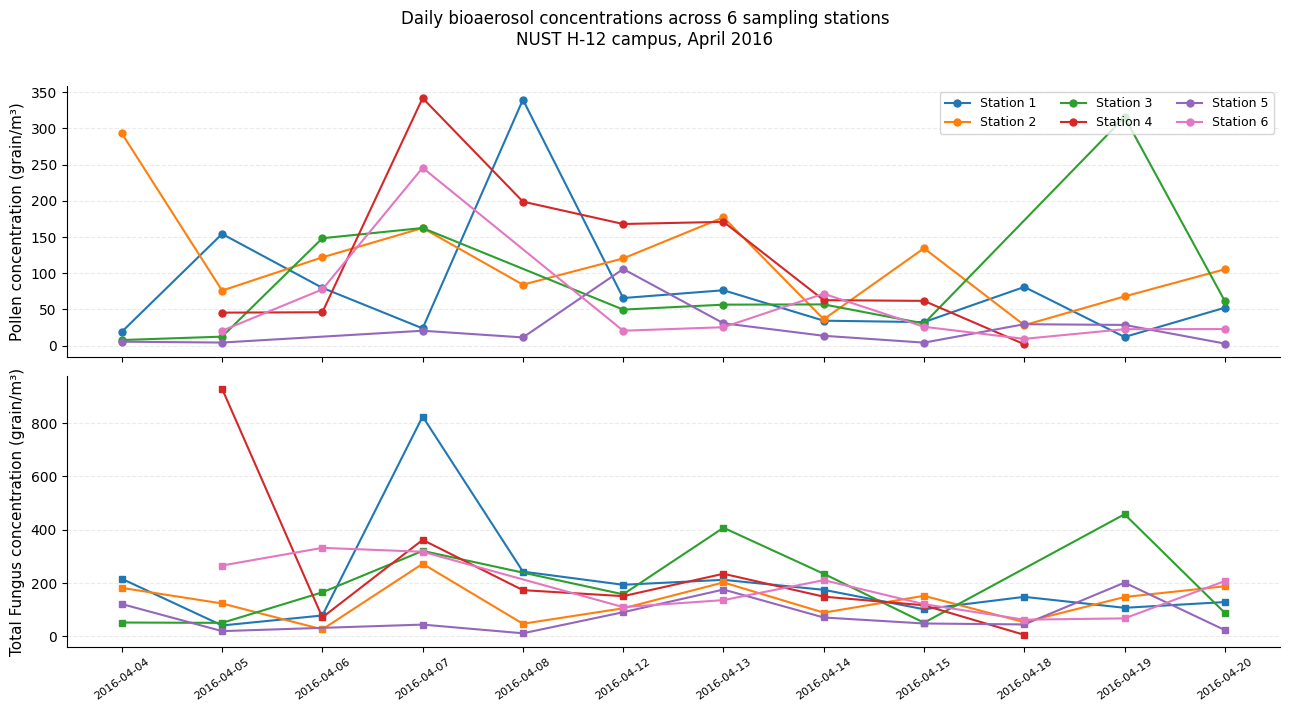

Saved: fig_timeseries.png


In [48]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
palette = plt.cm.tab10(np.linspace(0, 0.6, 6))

for sta_i, sta in enumerate(sorted(df['station'].unique())):
    sub = df[df['station'] == sta].sort_values('date')
    axes[0].plot(sub['date'], sub['pollen_conc'],
                 marker='o', ms=5, label=f'Station {sta}',
                 color=palette[sta_i], lw=1.5)
    axes[1].plot(sub['date'], sub['fungus_conc'],
                 marker='s', ms=5, color=palette[sta_i], lw=1.5)

for ax, ylabel in zip(axes, ['Pollen concentration (grain/m³)',
                               'Total Fungus concentration (grain/m³)']):
    ax.set_ylabel(ylabel, fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='x', rotation=35, labelsize=8)
    ax.grid(axis='y', alpha=0.25, linestyle='--')

axes[0].legend(ncol=3, fontsize=9, loc='upper right', framealpha=0.8)
fig.suptitle('Daily bioaerosol concentrations across 6 sampling stations\nNUST H-12 campus, April 2016',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('fig_timeseries.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved: fig_timeseries.png')

## Figure 2 — Pearson correlation heatmap
### What Pearson correlation measures
Pearson r measures the **linear relationship** between two variables:  
- r = +1 → perfect positive linear relationship  
- r = 0  → no linear relationship  
- r = -1 → perfect negative linear relationship  

p-values test whether the correlation is significantly different from 0.

### Why we use it here
To identify which meteorological variables are most linearly associated  
with daily bioaerosol concentrations at each site.

### Important caveat
All 6 stations share a **single weather station** record.  
So correlations reflect **day-to-day temporal variation** only —  
not spatial differences between sites.

In [49]:
# ── Compute Pearson r and p-values for all feature × target pairs ──
corr_data = {}
pval_data = {}

for tcol in TARGETS:
    corr_data[tcol] = []
    pval_data[tcol] = []
    for feat in MET_FEATURES:
        # dropna to handle any missing values
        mask = df[[tcol, feat]].dropna()
        r, p = stats.pearsonr(mask[feat], mask[tcol])
        corr_data[tcol].append(round(r, 3))
        pval_data[tcol].append(p)

corr_df = pd.DataFrame(corr_data, index=FEAT_LABELS).T
pval_df  = pd.DataFrame(pval_data, index=FEAT_LABELS).T

# ── Print numeric table ─────────────────────────────────────────
print('Pearson correlation table (r values):')
print(corr_df.round(3).to_string())
print()
print('p-value table:')
print(pval_df.round(4).to_string())

Pearson correlation table (r values):
                    GHI   Temp     RH  Wind Speed  Pressure  sin(WD)  cos(WD)
pollen_conc      -0.088 -0.254  0.138      -0.083     0.162    0.119   -0.301
fungus_conc       0.024 -0.131  0.032      -0.082     0.058    0.169   -0.221
Aspergillus_conc -0.043 -0.178  0.095      -0.193     0.151    0.237   -0.302
Alternaria_conc  -0.002 -0.226  0.142       0.018     0.077    0.110   -0.183

p-value table:
                     GHI    Temp      RH  Wind Speed  Pressure  sin(WD)  cos(WD)
pollen_conc       0.4915  0.0428  0.2768      0.5165    0.1999   0.3479   0.0158
fungus_conc       0.8530  0.3011  0.8035      0.5216    0.6473   0.1815   0.0793
Aspergillus_conc  0.7384  0.1603  0.4537      0.1262    0.2348   0.0592   0.0155
Alternaria_conc   0.9901  0.0727  0.2625      0.8877    0.5464   0.3880   0.1467


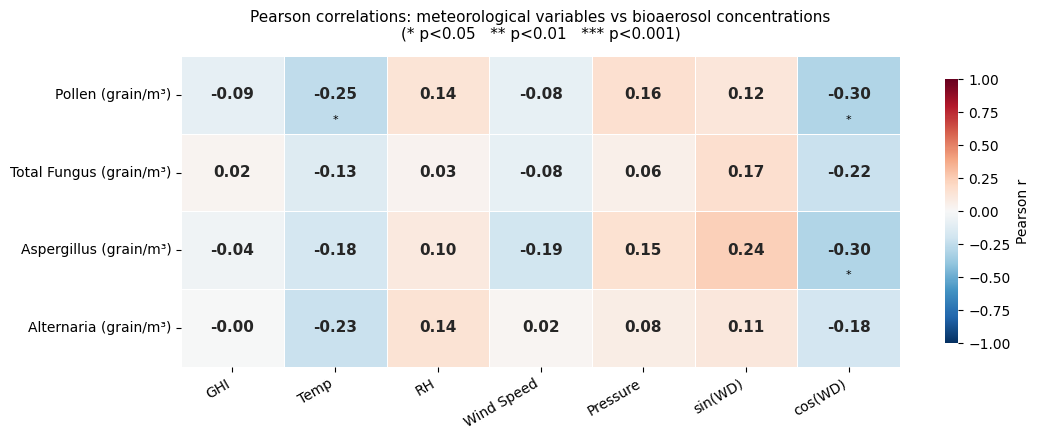

Saved: fig_pearson_heatmap.png


In [50]:
# ── Build heatmap with significance annotations ─────────────────
fig, ax = plt.subplots(figsize=(11, 4.5))

sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, center=0,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 11, 'weight': 'bold'},
            ax=ax,
            cbar_kws={'label': 'Pearson r', 'shrink': 0.85})

# Overlay significance stars below each cell value
for i, tcol in enumerate(TARGETS):
    for j, feat in enumerate(FEAT_LABELS):
        p   = pval_df.loc[tcol, feat]
        sym = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        if sym:
            ax.text(j + 0.5, i + 0.82, sym, ha='center', va='center',
                    fontsize=8, color='black')

ax.set_yticklabels([TARGETS[t] for t in TARGETS], rotation=0, fontsize=10)
ax.set_xticklabels(FEAT_LABELS, rotation=30, ha='right', fontsize=10)
ax.set_title('Pearson correlations: meteorological variables vs bioaerosol concentrations\n'
             '(* p<0.05   ** p<0.01   *** p<0.001)',
             fontsize=11, pad=12)
plt.tight_layout()
plt.savefig('fig_pearson_heatmap.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved: fig_pearson_heatmap.png')

## Per-site Pearson correlations
The heatmap above pools all stations. Now we compute per-site correlations  
as shown in Table 4 of the paper — this shows that Site 2 (open space)  
has the only significant wind speed correlations, while other sites show  
weak or inconsistent relationships.

In [51]:
print('Per-site Pearson correlations (r) — matching Table 4 in paper')
print('P = Pollen | F = Total Fungus')
print()

key_vars = ['GHI', 'Tamb', 'RH', 'WS']

for sta in range(1, 7):
    sub = df[df['station'] == sta]
    print(f'Station {sta}:')
    for feat in key_vars:
        for tcol, label in [('pollen_conc','P'), ('fungus_conc','F')]:
            pair = sub[[feat, tcol]].dropna()
            if len(pair) >= 4:
                r, p = stats.pearsonr(pair[feat], pair[tcol])
                sig  = '*' if p < 0.05 else ''
                print(f'  {label}:{feat:12s}  r={r:+.3f}  p={p:.3f} {sig}')
    print()

Per-site Pearson correlations (r) — matching Table 4 in paper
P = Pollen | F = Total Fungus

Station 1:
  P:GHI           r=+0.080  p=0.805 
  F:GHI           r=+0.112  p=0.729 
  P:Tamb          r=+0.018  p=0.956 
  F:Tamb          r=-0.186  p=0.564 
  P:RH            r=-0.134  p=0.679 
  F:RH            r=+0.093  p=0.774 
  P:WS            r=-0.582  p=0.047 *
  F:WS            r=-0.039  p=0.904 

Station 2:
  P:GHI           r=+0.374  p=0.232 
  F:GHI           r=+0.392  p=0.208 
  P:Tamb          r=-0.395  p=0.204 
  F:Tamb          r=+0.064  p=0.843 
  P:RH            r=+0.554  p=0.062 
  F:RH            r=-0.012  p=0.970 
  P:WS            r=+0.478  p=0.116 
  F:WS            r=+0.350  p=0.265 

Station 3:
  P:GHI           r=-0.800  p=0.005 *
  F:GHI           r=-0.298  p=0.403 
  P:Tamb          r=-0.375  p=0.286 
  F:Tamb          r=-0.141  p=0.697 
  P:RH            r=+0.101  p=0.782 
  F:RH            r=-0.045  p=0.902 
  P:WS            r=-0.138  p=0.704 
  F:WS            r